(data-exploratory-analysis)=
# Exploratory Data Analysis

Exploratory data analysis (EDA) involves taking a first look at a dataset and summarising its salient characteristics using tables and graphics. It is (or should be) the stage before testing hypotheses and can be useful in informing hypotheses. In this chapter, we'll look at a few options for EDA using code.

To show how to do EDA using code, we will need a dataset to explore. We'll use the Grinell housing dataset, which covers houses sold between 2005 and 2015 in Grinnell, Iowa. It was assembled by a local estate agent, Matt Karjalahti.

First, let's import a couple of essential packages:

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rich import print

In [2]:
import matplotlib_inline.backend_inline

# Plot settings
plt.style.use(
    "https://github.com/aeturrell/coding-for-economists/raw/main/plot_style.txt"
)
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

# Set max rows displayed for readability
pd.set_option("display.max_rows", 6)

warnings.filterwarnings("ignore")

```{note}
You may not have the **rich** package installed already. It provides pretty printing of text to screen (and much more besides). You can install it by running `pip install skimpy` or `conda install rich` on the command line.
```

## Preliminaries: extracting, typing, and initial cleaning

Let's grab some data to do exploratory data analysis on.

In [3]:
df = pd.read_csv(
    "https://vincentarelbundock.github.io/Rdatasets/csv/Stat2Data/GrinnellHouses.csv",
    index_col=0,
)
df.head()

,Date,Address,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct
rownames,,,,,,,,,,,,,,,
1,16695,1510 First Ave #112,2,1.0,1120.0,NaN,1993,2005,9,16,6.25,17000,10500,7000,66.67
2,16880,1020 Center St,3,1.0,1224.0,0.172176,1900,2006,3,20,22.06,35000,35000,27000,77.14
3,16875,918 Chatterton St,4,1.0,1540.0,NaN,1970,2006,3,15,18.18,54000,47000,28000,59.57
4,16833,1023 & 1025 Spring St.,3,1.0,1154.0,NaN,1900,2006,2,1,26.00,65000,49000,30000,61.22
5,16667,503 2nd Ave,3,1.0,1277.0,0.206612,1900,2005,8,19,24.08,35000,35000,30750,87.86


There are some things we should do even before an exploratory data analysis; we should make sure we've cast the columns to the right types and converted any that need converting. Even a quick look at the data provided by `.head()` shows that the `Date` column is in a weird format. It also *seems* like the number of `Baths` column has some data issues because it is a floating point number rather than an integer. However, this a North American quirk: realtors refer to bathrooms with only a toilet and sink as a "half bath" (and sometimes those with a shower but no bathtub as a "three-quarter bath," which also shows up in the data). So this is okay, and we mainly need concern ourselves with the Date column.

Fortunately, there is guidance attached to the dataset as to what the Date column really means: it's just a counter of days that encodes the date of sale that begins with 1st Jan 2005=16436. The documents also tell us that the final year is 2015. We'd really like to have a more usable datetime column than this so let's sort this out first. Ideally, we'd like to *map* the `Date` column into a new `datetime` column that turns 16436 into 1st Jan 2005, 16437 into 2nd Jan 2005, and so on, until we have a mapping for every date between the first date in the dataset and the last.

Our solution will be to create a function that maps the code for Date into a genuine datetime using the `pd.DateOffset` function and apply it to the `Date` column using `apply()`:

In [4]:
def convert_date_code_to_datetime(date):
    start_code = 16436
    return pd.to_datetime("01-01-2005") + pd.DateOffset(days=date - start_code)


df["datetime"] = df["Date"].apply(convert_date_code_to_datetime)
# Check the 'biggest' rows by datetime
df.nlargest(5, columns=["datetime"])

,Date,Address,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct,datetime
rownames,,,,,,,,,,,,,,,,
915,20186,957 350th Ave,3,2.00,1700.0,11.430000,1966,2015,4,8,128.82,229000,229000,219000,95.63,2015-04-09
886,20185,232 4th Ave W,3,2.50,NaN,0.139991,2004,2015,4,7,0.00,137500,137500,128500,93.45,2015-04-08
905,20185,1726 Summer St,4,1.75,1512.0,0.530000,1996,2015,4,7,125.00,239900,219900,189000,85.95,2015-04-08
920,20184,108 East St,4,3.00,1650.0,0.320000,2013,2015,4,6,156.97,259000,259000,259000,100.00,2015-04-07
834,20181,1405 Prince St,3,1.50,1094.0,NaN,1900,2015,4,3,18.28,32500,32500,20000,61.54,2015-04-04


An extra column containing datetime has been added and, looking at the max rows, we can see that it does indeed run all the way to 2015 as expected from the documentation of the dataset.

Okay, now we want to sort out the data type issues we saw earlier. But let's just check they're as bad as we think using `df.info()`

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929 entries, 1 to 929
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         929 non-null    int64         
 1   Address      929 non-null    object        
 2   Bedrooms     929 non-null    int64         
 3   Baths        929 non-null    float64       
 4   SquareFeet   911 non-null    float64       
 5   LotSize      741 non-null    float64       
 6   YearBuilt    929 non-null    int64         
 7   YearSold     929 non-null    int64         
 8   MonthSold    929 non-null    int64         
 9   DaySold      929 non-null    int64         
 10  CostPerSqFt  929 non-null    float64       
 11  OrigPrice    929 non-null    int64         
 12  ListPrice    929 non-null    int64         
 13  SalePrice    929 non-null    int64         
 14  SPLPPct      929 non-null    float64       
 15  datetime     929 non-null    datetime64[ns]
dtypes: datetime64

**pandas** read most of them in sensibly, but not *all* of them, so let's adjust the ones we need to:

In [6]:
df = df.assign(
    Address=df["Address"].astype("string"),
    Bedrooms=df["Bedrooms"].astype("category"),
    OrigPrice=df["OrigPrice"].astype(float),
    ListPrice=df["ListPrice"].astype(float),
    SalePrice=df["SalePrice"].astype(float),
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929 entries, 1 to 929
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         929 non-null    int64         
 1   Address      929 non-null    string        
 2   Bedrooms     929 non-null    category      
 3   Baths        929 non-null    float64       
 4   SquareFeet   911 non-null    float64       
 5   LotSize      741 non-null    float64       
 6   YearBuilt    929 non-null    int64         
 7   YearSold     929 non-null    int64         
 8   MonthSold    929 non-null    int64         
 9   DaySold      929 non-null    int64         
 10  CostPerSqFt  929 non-null    float64       
 11  OrigPrice    929 non-null    float64       
 12  ListPrice    929 non-null    float64       
 13  SalePrice    929 non-null    float64       
 14  SPLPPct      929 non-null    float64       
 15  datetime     929 non-null    datetime64[ns]
dtypes: category(1

Having to do some initial variable type cleaning is a *normal* and *unavoidable* part of data analysis, especially when reading in from a format like CSV (which does not preserve data type but has great interoperability across systems). It's important and what we've seen here is a typical pattern.

There's just one more step before starting the EDA proper. If you haven't reached the Chapter on best practice, which talks about naming conventions, you won't know this yet but the usual naming convention for variables and columns in Python is so-called snake case (appropriately enough). An example of a word *not* in snake case would be 'ThisIsAColName'; actually that's in Camel Case. Rendered in snake case, it would be 'this_is_a_col_name', which is longer but slightly easier to read. So we should really change the column names to be in snake case. Fortunately, the [**skimpy**](https://aeturrell.github.io/skimpy/) package (drawing on functions from a package called **dataprep**) has us covered here; it provides methods to translate between pretty much every naming convention that exists. Let's change our columns to snake case, which is the default setting of `clean_columns()`.

```{note}
**skimpy** is likely to be a new package to you, and one that you haven't installed. You can install it by running `pip install skimpy` on the command line.
```

In [7]:
!pip install skimpy
from skimpy import clean_columns

df = clean_columns(df, case="snake")
print(df.columns)

Index(['date', 'address', 'bedrooms', 'baths', 'square_feet', 'lot_size',
       'year_built', 'year_sold', 'month_sold', 'day_sold', 'cost_per_sq_ft',
       'orig_price', 'list_price', 'sale_price', 'splp_pct', 'datetime'],
      dtype='object')

Now we can start the exploratory data analysis!

## EDA using **pandas** built-in methods

**pandas** has some great options for built-in EDA; in fact we've already seen one of them, `df.info()` which, as well as reporting datatypes and memory usage, also tells us how many observations in each column are 'truthy' rather than 'falsy', ie how many have non-null values.

### Exploratory tables and descriptive statistics

A small step beyond `df.info()` to get tables is to use `df.describe()` which, if you have mixed datatypes that include floats, will report some basic summary statistics:

In [8]:
df.describe()

,date,baths,square_feet,lot_size,year_built,year_sold,month_sold,day_sold,cost_per_sq_ft,orig_price,list_price,sale_price,splp_pct,datetime
count,929.000000,929.000000,911.000000,741.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929
mean,18223.215285,1.779333,1583.215148,0.723463,1945.903122,2009.365985,6.831001,16.226050,83.291561,146047.083961,141399.138859,133203.720129,93.563994,2009-11-23 05:10:00.645855744
min,16527.000000,0.000000,640.000000,0.028926,1870.000000,2005.000000,1.000000,1.000000,0.000000,5990.000000,10500.000000,7000.000000,46.500000,2005-04-02 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75%,19281.000000,2.000000,1833.000000,0.370179,1973.000000,2012.000000,9.000000,25.000000,105.770000,179000.000000,172000.000000,162500.000000,97.560000,2012-10-16 00:00:00
max,20186.000000,6.000000,6815.000000,55.000000,2013.000000,2015.000000,12.000000,31.000000,258.790000,695000.000000,695000.000000,606000.000000,111.020000,2015-04-09 00:00:00
std,1139.171002,0.743154,655.664966,2.725697,37.209902,3.124149,3.035790,9.396815,35.762241,85174.109372,82228.201763,77959.624697,6.953764,NaN


Although helpful, that sure is hard to read! We can improve this by using the `round()` method too:


In [9]:
sum_table = df.describe().round(1)
sum_table

,date,baths,square_feet,lot_size,year_built,year_sold,month_sold,day_sold,cost_per_sq_ft,orig_price,list_price,sale_price,splp_pct,datetime
count,929.0,929.0,911.0,741.0,929.0,929.0,929.0,929.0,929.0,929.0,929.0,929.0,929.0,929
mean,18223.2,1.8,1583.2,0.7,1945.9,2009.4,6.8,16.2,83.3,146047.1,141399.1,133203.7,93.6,2009-11-23 05:10:00.645855744
min,16527.0,0.0,640.0,0.0,1870.0,2005.0,1.0,1.0,0.0,5990.0,10500.0,7000.0,46.5,2005-04-02 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75%,19281.0,2.0,1833.0,0.4,1973.0,2012.0,9.0,25.0,105.8,179000.0,172000.0,162500.0,97.6,2012-10-16 00:00:00
max,20186.0,6.0,6815.0,55.0,2013.0,2015.0,12.0,31.0,258.8,695000.0,695000.0,606000.0,111.0,2015-04-09 00:00:00
std,1139.2,0.7,655.7,2.7,37.2,3.1,3.0,9.4,35.8,85174.1,82228.2,77959.6,7.0,NaN


Published summary statistics tables often list one variable per row, and if your dataframe has many variables, `describe()` can quickly get too wide to read easily. You can transpose it using the `T` property (or the `transpose()` method):

In [10]:
sum_table = sum_table.T
sum_table

,count,mean,min,25%,50%,75%,max,std
date,929.0,18223.2,16527.0,17169.0,18046.0,19281.0,20186.0,1139.2
baths,929.0,1.8,0.0,1.0,1.8,2.0,6.0,0.7
square_feet,911.0,1583.2,640.0,1150.0,1440.0,1833.0,6815.0,655.7
...,...,...,...,...,...,...,...,...
sale_price,929.0,133203.7,7000.0,83000.0,119340.0,162500.0,606000.0,77959.6
splp_pct,929.0,93.6,46.5,91.3,94.9,97.6,111.0,7.0
datetime,929,2009-11-23 05:10:00.645855744,2005-04-02 00:00:00,2007-01-04 00:00:00,2009-05-30 00:00:00,2012-10-16 00:00:00,2015-04-09 00:00:00,NaN


Now, although this is very basic, let's say you wanted to include it as a table of summary statistics in a paper. This is just a dataframe so you can export it just like you can *any* pandas dataframe. This includes options like `.to_excel()`. For inclusion in a paper or report, you're most likely to want to export it as one of a few common types, all of which can be achieved using the `to_formatname()` syntax (for example `to_string()` for plain text). Just to demonstrate these different output types, let's print them to screen (even though in practice we'd be writing them to a file). First, as text:

In [11]:
print(sum_table.to_string())

count                           mean                  min                  25%                  50%
75%                  max      std
date            929.0                        18223.2              16527.0              17169.0              18046.0
19281.0              20186.0   1139.2
baths           929.0                            1.8                  0.0                  1.0                  1.8
2.0                  6.0      0.7
square_feet     911.0                         1583.2                640.0               1150.0               1440.0
1833.0               6815.0    655.7
lot_size        741.0                            0.7                  0.0                  0.2                  0.3
0.4                 55.0      2.7
year_built      929.0                         1945.9               1870.0               1900.0               1956.0
1973.0               2013.0     37.2
year_sold       929.0                         2009.4               2005.0               2007.0               2009.0
2012.0               2015.0      3.1
month_sold      929.0                            6.8                  1.0                  5.0                  7.0
9.0                 12.0      3.0
day_sold        929.0                           16.2                  1.0                  8.0                 16.0
25.0                 31.0      9.4
cost_per_sq_ft  929.0                           83.3                  0.0                 60.8                 82.9
105.8                258.8     35.8
orig_price      929.0                       146047.1               5990.0              89900.0             129900.0
179000.0             695000.0  85174.1
list_price      929.0                       141399.1              10500.0              88000.0             125000.0
172000.0             695000.0  82228.2
sale_price      929.0                       133203.7               7000.0              83000.0             119340.0
162500.0             606000.0  77959.6
splp_pct        929.0                           93.6                 46.5                 91.3                 94.9
97.6                111.0      7.0
datetime          929  2009-11-23 05:10:00.645855744  2005-04-02 00:00:00  2007-01-04 00:00:00  2009-05-30 00:00:00
2012-10-16 00:00:00  2015-04-09 00:00:00      NaN

as Markdown:


In [12]:
print(sum_table.to_markdown())

|                |   count | mean                          | min                 | 25%                 | 50%       
| 75%                 | max                 |     std |
|:---------------|--------:|:------------------------------|:--------------------|:--------------------|:----------
----------|:--------------------|:--------------------|--------:|
| date           |     929 | 18223.2                       | 16527.0             | 17169.0             | 18046.0   
| 19281.0             | 20186.0             |  1139.2 |
| baths          |     929 | 1.8                           | 0.0                 | 1.0                 | 1.8       
| 2.0                 | 6.0                 |     0.7 |
| square_feet    |     911 | 1583.2                        | 640.0               | 1150.0              | 1440.0    
| 1833.0              | 6815.0              |   655.7 |
| lot_size       |     741 | 0.7                           | 0.0                 | 0.2                 | 0.3       
| 0.4                 | 55.0                |     2.7 |
| year_built     |     929 | 1945.9                        | 1870.0              | 1900.0              | 1956.0    
| 1973.0              | 2013.0              |    37.2 |
| year_sold      |     929 | 2009.4                        | 2005.0              | 2007.0              | 2009.0    
| 2012.0              | 2015.0              |     3.1 |
| month_sold     |     929 | 6.8                           | 1.0                 | 5.0                 | 7.0       
| 9.0                 | 12.0                |     3   |
| day_sold       |     929 | 16.2                          | 1.0                 | 8.0                 | 16.0      
| 25.0                | 31.0                |     9.4 |
| cost_per_sq_ft |     929 | 83.3                          | 0.0                 | 60.8                | 82.9      
| 105.8               | 258.8               |    35.8 |
| orig_price     |     929 | 146047.1                      | 5990.0              | 89900.0             | 129900.0  
| 179000.0            | 695000.0            | 85174.1 |
| list_price     |     929 | 141399.1                      | 10500.0             | 88000.0             | 125000.0  
| 172000.0            | 695000.0            | 82228.2 |
| sale_price     |     929 | 133203.7                      | 7000.0              | 83000.0             | 119340.0  
| 162500.0            | 606000.0            | 77959.6 |
| splp_pct       |     929 | 93.6                          | 46.5                | 91.3                | 94.9      
| 97.6                | 111.0               |     7   |
| datetime       |     929 | 2009-11-23 05:10:00.645855744 | 2005-04-02 00:00:00 | 2007-01-04 00:00:00 | 2009-05-30
00:00:00 | 2012-10-16 00:00:00 | 2015-04-09 00:00:00 |   nan   |

as HTML:

In [13]:
print(sum_table.head(3).to_html())

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>count</th>
      <th>mean</th>
      <th>min</th>
      <th>25%</th>
      <th>50%</th>
      <th>75%</th>
      <th>max</th>
      <th>std</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>date</th>
      <td>929.0</td>
      <td>18223.2</td>
      <td>16527.0</td>
      <td>17169.0</td>
      <td>18046.0</td>
      <td>19281.0</td>
      <td>20186.0</td>
      <td>1139.2</td>
    </tr>
    <tr>
      <th>baths</th>
      <td>929.0</td>
      <td>1.8</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>1.8</td>
      <td>2.0</td>
      <td>6.0</td>
      <td>0.7</td>
    </tr>
    <tr>
      <th>square_feet</th>
      <td>911.0</td>
      <td>1583.2</td>
      <td>640.0</td>
      <td>1150.0</td>
      <td>1440.0</td>
      <td>1833.0</td>
      <td>6815.0</td>
      <td>655.7</td>
    </tr>
  </tbody>
</table>

or as latex:

In [14]:
print(sum_table.style.to_latex(caption="Summary stats from EDA"))

\begin{table}
\caption{Summary stats from EDA}
\begin{tabular}{lllllllll}
 & count & mean & min & 25% & 50% & 75% & max & std \\
date & 929.000000 & 18223.200000 & 16527.000000 & 17169.000000 & 18046.000000 & 19281.000000 & 20186.000000 & 
1139.200000 \\
baths & 929.000000 & 1.800000 & 0.000000 & 1.000000 & 1.800000 & 2.000000 & 6.000000 & 0.700000 \\
square_feet & 911.000000 & 1583.200000 & 640.000000 & 1150.000000 & 1440.000000 & 1833.000000 & 6815.000000 & 
655.700000 \\
lot_size & 741.000000 & 0.700000 & 0.000000 & 0.200000 & 0.300000 & 0.400000 & 55.000000 & 2.700000 \\
year_built & 929.000000 & 1945.900000 & 1870.000000 & 1900.000000 & 1956.000000 & 1973.000000 & 2013.000000 & 
37.200000 \\
year_sold & 929.000000 & 2009.400000 & 2005.000000 & 2007.000000 & 2009.000000 & 2012.000000 & 2015.000000 & 
3.100000 \\
month_sold & 929.000000 & 6.800000 & 1.000000 & 5.000000 & 7.000000 & 9.000000 & 12.000000 & 3.000000 \\
day_sold & 929.000000 & 16.200000 & 1.000000 & 8.000000 & 16.000000 & 25.000000 & 31.000000 & 9.400000 \\
cost_per_sq_ft & 929.000000 & 83.300000 & 0.000000 & 60.800000 & 82.900000 & 105.800000 & 258.800000 & 35.800000 \\
orig_price & 929.000000 & 146047.100000 & 5990.000000 & 89900.000000 & 129900.000000 & 179000.000000 & 
695000.000000 & 85174.100000 \\
list_price & 929.000000 & 141399.100000 & 10500.000000 & 88000.000000 & 125000.000000 & 172000.000000 & 
695000.000000 & 82228.200000 \\
sale_price & 929.000000 & 133203.700000 & 7000.000000 & 83000.000000 & 119340.000000 & 162500.000000 & 
606000.000000 & 77959.600000 \\
splp_pct & 929.000000 & 93.600000 & 46.500000 & 91.300000 & 94.900000 & 97.600000 & 111.000000 & 7.000000 \\
datetime & 929 & 2009-11-23 05:10:00.645855744 & 2005-04-02 00:00:00 & 2007-01-04 00:00:00 & 2009-05-30 00:00:00 & 
2012-10-16 00:00:00 & 2015-04-09 00:00:00 & nan \\
\end{tabular}
\end{table}

And remember, with all of these, you can write them to file using a variation on the following structure:

```python

open('sum_stats_table.tex', 'w').write(sum_table.style.to_latex(caption='Summary stats from EDA'))

```

Of course, the stats provided in this pre-built table are not very customised. So what do we do to get the table that we actually want? Well, the answer is to draw on the contents of the previous data chapters, particularly the introduction to data analysis. Groupbys, merges, aggregations: use all of them to produce the EDA table that you want.

If you're exploring data, you might also want to be able to read everything clearly and see any deviations from what you'd expect quickly. **pandas** has some built-in functionality that styles dataframes to help you. These styles persist when you export the dataframe to, say, Excel, too.

```{note}
For some styling features, for example `style.format()`, you will need an up to date version of **pandas**. You can run `pip install -U pandas` on the command line to update a pip-installed **pandas** package, or `conda update pandas` for conda.
```

Here's an example that highlights some ways of styling dataframes, making use of several features such as: unstacking into a wider format (`unstack()`), changing the units (`lambda` function; note that `1e3` is shorthand for `1000` on computers), fill NaNs with unobtrusive strings (`.fillna('-')`), removing numbers after the decimal place (`.style.format(precision=0)`), and adding a caption (`.style.set_caption`).

In [15]:
(
    df.groupby(["year_sold", "bedrooms"])["sale_price"]
    .mean()
    .unstack()
    .apply(lambda x: x / 1e3)
    .fillna("-")
    .style.format(precision=0)
    .set_caption("Sale price (thousands)")
)

bedrooms,0,1,2,3,4,5,6,7,8
year_sold,,,,,,,,,
2005,155,-,82,112,141,174,205,81,-
2006,25,-,80,125,139,281,-,-,205
2007,-,-,83,110,171,245,400,-,-
2008,238,62,82,132,158,236,221,-,-
2009,-,84,78,104,129,159,-,-,-
2010,-,-,68,120,161,195,-,-,-
2011,128,-,83,128,176,213,-,-,-
2012,191,38,98,132,154,213,305,-,-
2013,382,88,77,129,197,182,141,-,-


(Another way to achieve the `groupby()`, `mean()`, and `unstack()` steps in one step is using `df.pivot_table(index="YearSold", columns="Bedrooms", values="SalePrice", aggfunc=np.mean`.)

Although a neater one than we've seen, this is still a drab table of numbers. The eye is not immediately drawn to it!

To remedy that, let's take a look at another styling technique: the use of colour. Let's say we wanted to make a table that showed a cross-tabulation between year and number of bathrooms; that is the counts of objects appearing in both of these fields according to the categories, eg in 2015, there were *5* houses with 2 bathrooms. This is different to what we did before, which was the mean price based on groups of houses by number of bathrooms and year.

To perform a cross-tabulation, we'll use the built-in `pd.crosstab()` but we'll ask that the values that appear in the table (counts) be lit up with a heatmap using `style.background_gradient()` too:

In [16]:
pd.crosstab(df["bedrooms"], df["year_sold"]).style.background_gradient(cmap="plasma")

year_sold,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
bedrooms,,,,,,,,,,,
0,1,1,0,1,0,0,3,3,1,2,0
1,0,0,0,2,1,0,0,1,2,1,0
2,15,18,24,17,14,10,10,11,18,11,1
3,54,64,56,59,25,27,31,47,39,46,15
4,21,39,24,17,10,14,14,28,28,30,3
5,7,8,6,8,3,2,8,6,4,9,0
6,1,0,1,2,0,0,0,1,2,0,0
7,1,0,0,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,0,0,0


By default, `background_gradient()` highlights each number relative to the others in its column; you can highlight by row using `axis=1` or relative to all table values using `axis=0`. And of course `plasma` is just one of [many available colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html)!

```{admonition} Exercise
Do a new cross-tabulation using a different colourmap.
```

Here are a couple of other styling tips for dataframes.

First, use bars to show ordering:

In [17]:
(
    df.iloc[:10, -6:-1]
    .style.format(precision=0)
    .bar(subset=["cost_per_sq_ft", "sale_price"], color="#d65f5f")
)

,cost_per_sq_ft,orig_price,list_price,sale_price,splp_pct
rownames,,,,,
1,6,17000,10500,7000,67
2,22,35000,35000,27000,77
3,18,54000,47000,28000,60
4,26,65000,49000,30000,61
5,24,35000,35000,30750,88
6,39,45900,45900,42000,92
7,60,62500,56500,46000,81
8,43,54500,52500,49500,94
9,55,59900,52500,50000,95


Second, use `format()` to add informative suffixes and round numbers appropriately:

In [18]:
df.groupby(["bedrooms"])[["splp_pct"]].mean().style.format("{:.0f}%")

,splp_pct
bedrooms,
0,97%
1,89%
2,92%
3,94%
4,94%
5,93%
6,90%
7,95%
8,82%


Third, use `.hightlight_max()`, and similar commands, to show important entries:

In [19]:
df.iloc[:10, -6:-1].style.highlight_max().format("{:.0f}")

,cost_per_sq_ft,orig_price,list_price,sale_price,splp_pct
rownames,,,,,
1,6,17000,10500,7000,67
2,22,35000,35000,27000,77
3,18,54000,47000,28000,60
4,26,65000,49000,30000,61
5,24,35000,35000,30750,88
6,39,45900,45900,42000,92
7,60,62500,56500,46000,81
8,43,54500,52500,49500,94
9,55,59900,52500,50000,95


You can find a full set of styling commands [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/style.html).

### Exploratory plotting

**pandas** has some built-in plotting options to help you look at data quickly. These can be accessed via `.plot.*` or `.plot()`, depending on the context. Let's make a quick `.plot()` of the mean quarterly nominal Sale Price over time (with extra options passed via keyword arguments):

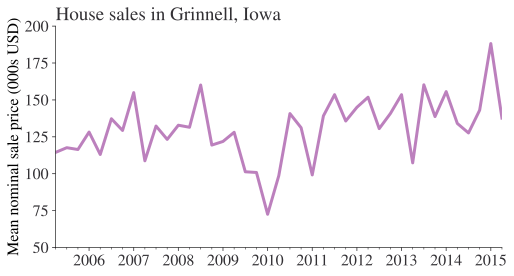

In [20]:
(
    df.set_index("datetime")
    .groupby(pd.Grouper(freq="3M"))["sale_price"]
    .mean()
    .apply(lambda x: x / 1e3)
    .plot(
        title="House sales in Grinnell, Iowa",
        xlabel="",
        ylabel="Mean nominal sale price (000s USD)",
    )
);

Again, if you can get the data in the right shape, you can plot it. The same function works with multiple lines


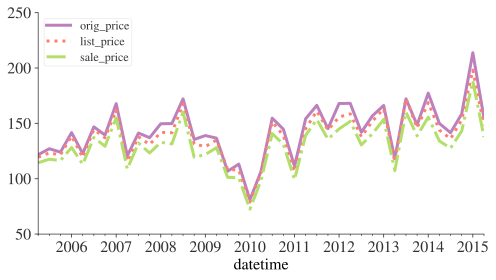

In [21]:
(
    df.set_index("datetime")
    .groupby(pd.Grouper(freq="3M"))[["orig_price", "list_price", "sale_price"]]
    .mean()
    .apply(lambda x: x / 1e3)
    .plot(style=["-", ":", "-."])
);

Now let's see some of the other quick `.plot.*()` options.

Here's a kernel density estimation (KDE) plot. Just to show what's possible, we'll use the `df.columnname` syntax, an alternative to `df['columnname']`, and set limits via keyword arguments.

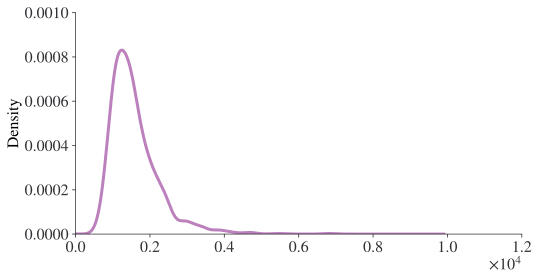

In [22]:
df.square_feet.plot.kde(ylim=(0, None), xlim=(0, None));

A bar chart (use `barh()` for horizontal orientation; `rot` sets rotation of labels):

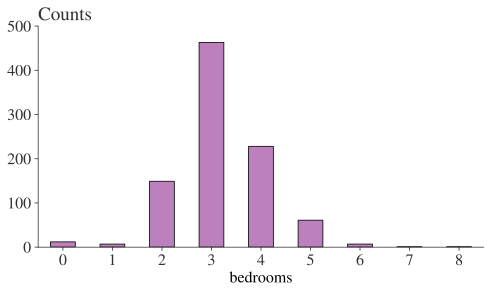

In [23]:
df.value_counts("bedrooms").sort_index().plot.bar(title="Counts", rot=0);

This chart shows why EDA is so important: if we are modelling residential housing, and we find that there are observations that don't have *any* bedrooms, perhaps they should be excluded from the downstream analysis.


This next one, using `.plot.hist()`, provides another instructive example of how EDA can reveal interesting issues with datasets. First, there are many more houses built in 1900 than seem plausible and, checking the documentation for the dataset, it does say that when a construction date is not known, it is entered as 1900-which explains what's going on here. Second, some of the construction years are in the future! Is this plausible? It could be. Some houses are sold before the construction of an estate is completed; this could be the case here.

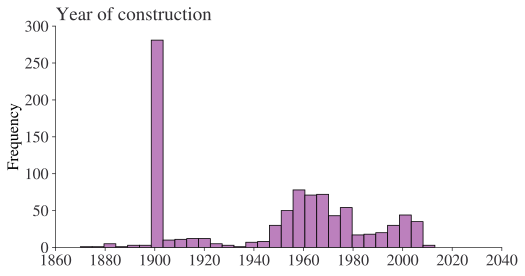

In [24]:
df["year_built"].plot.hist(bins=30, title="Year of construction");

Boxplot:

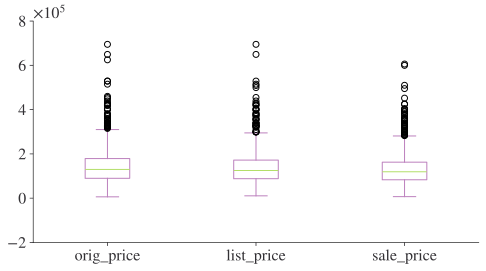

In [25]:
(df[["orig_price", "list_price", "sale_price"]].plot.box());

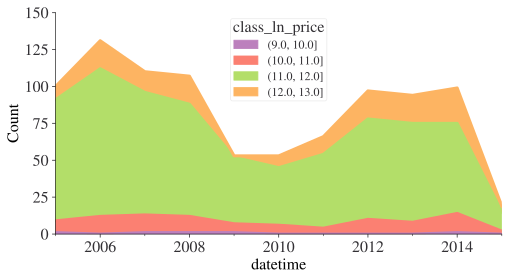

In [26]:
df["class_ln_price"] = pd.cut(np.log(df["orig_price"]), bins=4, precision=0)

(
    df.set_index("datetime")
    .groupby([pd.Grouper(freq="A"), "class_ln_price"])["class_ln_price"]
    .count()
    .unstack()
    .plot.area(ylabel="Count")
);

Scatter plot:

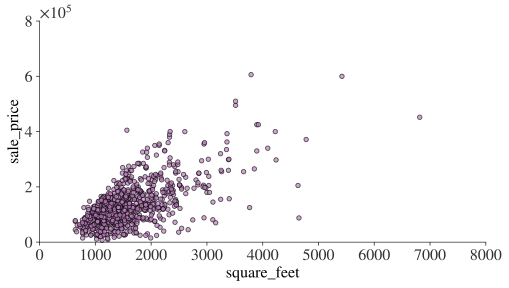

In [27]:
df.plot.scatter(x="square_feet", y="sale_price", alpha=0.7, ylim=(0, None));

Hexbin:

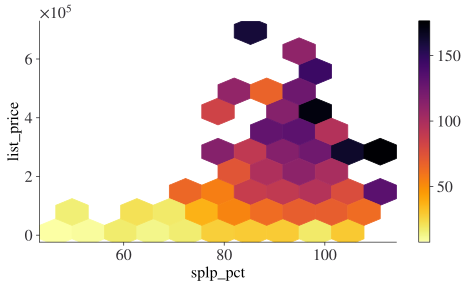

In [28]:
df.plot.hexbin(
    y="list_price",
    x="splp_pct",
    gridsize=10,
    cmap="inferno_r",
    C="cost_per_sq_ft",
    sharex=False,
);

## **skimpy** for summary statistics

The **skimpy** package is a light weight tool that provides summary statistics about variables in data frames in the console (rather than in a big HTML report, which is what the other EDA packages in the rest of this chapter too). Sometimes `df.summary()` isn't enough but a HTML report is too much, and **skimpy** fills this gap. Let's see it in action.

In [29]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 929    │ │ float64     │ 8     │ │ bedrooms              │                                │
│ │ Number of columns │ 17     │ │ int64       │ 5     │ │ class_ln_price        │                                │
│ └───────────────────┴────────┘ │ category    │ 2     │ └───────────────────────┘                                │
│                                │ string      │ 1     │                                                          │
│                                │ datetime64  │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column       ┃ NA  ┃ NA %         ┃ mean   ┃ sd     ┃ p0      ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ date         │   0 │            0 │  18220 │   1139 │   16530 │  17170 │  18050 │  19280 │  20190 │ █▇▃▄▅▆ │  │
│ │ baths        │   0 │            0 │  1.779 │ 0.7432 │       0 │      1 │   1.75 │      2 │      6 │   █▃▁  │  │
│ │ square_feet  │  18 │ 1.9375672766 │   1583 │  655.7 │     640 │   1150 │   1440 │   1833 │   6815 │  █▃▁   │  │
│ │              │     │       415502 │        │        │         │        │        │        │        │        │  │
│ │ lot_size     │ 188 │ 20.236813778 │ 0.7235 │  2.726 │ 0.02893 │ 0.2339 │ 0.2841 │ 0.3702 │     55 │   █    │  │
│ │              │     │       256188 │        │        │         │        │        │        │        │        │  │
│ │ year_built   │   0 │            0 │   1946 │  37.21 │    1870 │   1900 │   1956 │   1973 │   2013 │  █▁▆▅▃ │  │
│ │ year_sold    │   0 │            0 │   2009 │  3.124 │    2005 │   2007 │   2009 │   2012 │   2015 │ ██▂▄▇▄ │  │
│ │ month_sold   │   0 │            0 │  6.831 │  3.036 │       1 │      5 │      7 │      9 │     12 │ ▃▅██▆▅ │  │
│ │ day_sold     │   0 │            0 │  16.23 │  9.397 │       1 │      8 │     16 │     25 │     31 │ ▆▅▅▅▆█ │  │
│ │ cost_per_sq_ │   0 │            0 │  83.29 │  35.76 │       0 │  60.82 │  82.88 │  105.8 │  258.8 │  ▂█▇▂  │  │
│ │ ft           │     │              │        │        │         │        │        │        │        │        │  │
│ │ orig_price   │   0 │            0 │ 146000 │  85170 │    5990 │  89900 │ 129900 │ 179000 │ 695000 │  ██▂   │  │
│ │ list_price   │   0 │            0 │ 141400 │  82230 │   10500 │  88000 │ 125000 │ 172000 │ 695000 │  █▇▁   │  │
│ │ sale_price   │   0 │            0 │ 133200 │  77960 │    7000 │  83000 │ 119300 │ 162500 │ 606000 │  ▇█▂▁  │  │
│ │ splp_pct     │   0 │            0 │  93.56 │  6.954 │    46.5 │  91.32 │  94.92 │  97.56 │    111 │    ▁█  │  │
│ └──────────────┴─────┴──────────────┴────────┴────────┴─────────┴────────┴────────┴────────┴────────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                ┃ NA       ┃ N

```{admonition} Exercise
Apply exploratory data analysis to the 'titanic' dataset, which can be loaded from [this link](https://github.com/datasciencedojo/datasets/raw/master/titanic.csv).

First run **skimpy**'s `skim()` function. Then see what analysis you can do using **pandas** built-in exploratory methods.

```

## The **ydata-profiling** package

The EDA we did using the built-in **pandas** functions was a bit limited and user-input heavy. The [**ydata-profiling**](https://docs.profiling.ydata.ai/) library aims to automate the legwork of EDA for you. It generates 'profile' reports from a pandas DataFrame. For each column, many statistics are computed and then relayed in an interactive HTML report.

Let's generate a report on our dataset using the `minimal=True` setting (the default settings produce a lot of computationally expensive extras):


In [31]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df, minimal=True, title="Profiling Report: Grinnell House Sales"
)
profile.to_notebook_iframe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 85.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

This is a full on report about everything in our dataset! We can see, for instance, that we have 17 numerical variables, 0 boolean, and 4 categorical (which includes string), and 1 datetime. The overview also tells us the number of observations, that we have 1.2% of values missing across all columns, and we have zero duplicates.

The warnings page shows where **pandas-profiling** really shines. It flags *potential* issues with the data that should be taken into account in any subsequent analysis. For example, although not relevant here, the report will say if there are very unbalanced classes in a low cardinality categorical variable.

Let's explore a couple of the warnings that have been raised. `Address` has high cardinality; but that's okay, we expect most addresses to be different because the turn-over of houses is not that frequent. We also see that there are a lot of missing values for `LotSize`.

Now let's dig down into a specific variable, `SalePrice`. You can view more about it using the 'Toggle details' button. We get four extra pages of detail about this variable, in addition to the headline statistics: a comprehensive page of descriptive statistics, a page with a histogram of the variable, a page with a table of common values, and a page of extreme values.

```{admonition} Exercise
Run **ydata-profiling** on the 'titanic' dataset.
```

## The **dataprep** package

The [**dataprep**](https://dataprep.ai/) package offers very similar functionality to **ydata-profiling**; it produces an in-depth report on the input data. There isn't much difference between them in general apart from it seems like **dataprep** has slightly better support for string column types and is a little bit richer on visualisations (it has interactive plots that you can change the axes of). It's well worth checking out as an alternative to **ydata-profiling**.

## Review

That's it for this very brief tour of exploratory data analysis with code. You should know now how to do simple analysis of **pandas** dataframes using techniques from other chapters to create summary statistics, using styling of tables of summary statistics, using the quick visualisation options that are built-in to **pandas**, and using the **skimpy** package. You should also know where to go for more in-depth, heavy duty exploratory data analysis reports, namely **ydata-profiling** and **dataprep**.